In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [121]:
R, C = 10 * 1E3, 4.7 * 1E-9 # Ohms, Farads
alpha = 1 / (R * C) # Hz

omega = 1E9 # Hz
A_in = 14.4 # V

T = 1/omega
#H_V = 1 / np.sqrt(1 + (omega / alpha)**2)
H_V = 1 / np.sqrt(1 + (omega / alpha)**2)
phi = np.arctan(-omega / alpha)

t = np.linspace(-T, T, 1000)
V_in, V_out = 0.5*A_in*np.sin(2*np.pi*omega * t), 0.5*A_in*H_V*np.sin(2*np.pi*omega*t - 2*np.pi*phi)
a_in, a_out = np.max(V_in)-np.min(V_in), np.max(V_out)-np.min(V_in)

print(f'A_in: {a_in} V')
print(f'A_out: {a_out} V')

A_in: 14.399982199131804 V
A_out: 7.200144290429954 V


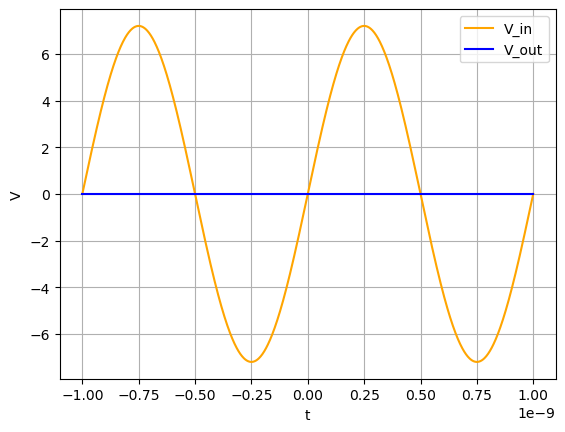

In [122]:
fig, ax = plt.subplots()
ax.plot(t, V_in, label="V_in", color = "orange")
ax.plot(t, V_out, label="V_out", color = "blue")
ax.set(xlabel="t", ylabel="V")
ax.grid(True)
plt.legend()
plt.show()

In [115]:
df = pd.read_csv("20250911_C2_SINE.csv")
df_Hv = (df["V_out[V]"] - df["noise[V]"]) / df["V_in[V]"]

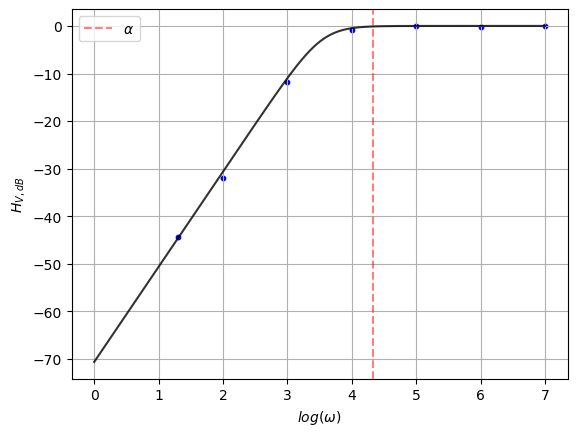

In [130]:
f = np.linspace(1, 1E7, int(1E6))
Omega = f*2*np.pi
#H_V_dB = 20 * np.log10(1 / np.sqrt(1 + (Omega / alpha)**2)) #low-pass filter
H_V_dB = 20 * np.log10(1 / np.sqrt(1 + (alpha / Omega)**2)) #high-pass filter
log_omega = np.log10(f)

fig, ax = plt.subplots()
ax.plot(log_omega, H_V_dB, color="k", alpha=0.8)
ax.scatter(np.log10(df["f_in[Hz]"]), 20 * np.log10(df_Hv), s = 10, marker="o", color="b")

ax.axvline(np.log10(alpha), color="r", ls="--", label=f"$\\alpha$", alpha = 0.5)
ax.set(xlabel="$log(\omega)$", ylabel="$H_{V,dB}$")
plt.legend()
plt.grid()
plt.show()

In [ ]:
fig, ax = plt.subplots()
ax.plot(log_omega,s, color="k", alpha=0.8)
ax.scatter(np.log10(df["f_in[Hz]"]), 20 * np.log10(df_Hv), s = 10, marker="o", color="b")

ax.axvline(np.log10(alpha), color="r", ls="--", label=f"$\\alpha$", alpha = 0.5)
ax.set(xlabel="$log(\omega)$", ylabel="$H_{V,dB}$")
plt.legend()
plt.grid()
plt.show()

In [126]:
'''weird filter'''
R1, R2, C = 220, 100, 0.68 * 1E-6 # Ohms, Farads
omega = 1E9 # Hz
A_in = 14.4 # V

T = 1/omega
z = R1*R2*omega*C-1/(omega*C)
H_V = np.sqrt((2*R2*(R1+2*R2)+z**2)**2+(z**2)*(R1**2)) / ((R1+2*R2)**2 + z**2)
phi = np.arctan(z*R1/(2*R2*(R1+2*R2)))

t = np.linspace(-T, T, 1000)
V_in, V_out = 0.5*A_in*np.sin(2*np.pi*omega * t), 0.5*A_in*H_V*np.sin(2*np.pi*omega*t - 2*np.pi*phi)
a_in, a_out = np.max(V_in)-np.min(V_in), np.max(V_out)-np.min(V_in)

print(f'A_in: {a_in} V')
print(f'A_out: {a_out} V')

A_in: 14.399982199131804 V
A_out: 14.399990741829647 V


In [144]:
df = pd.read_csv("20250911_C3_SINE.csv")
df_Hv = (df["V_out[V]"] - df["noise[V]"]) / df["V_in[V]"]

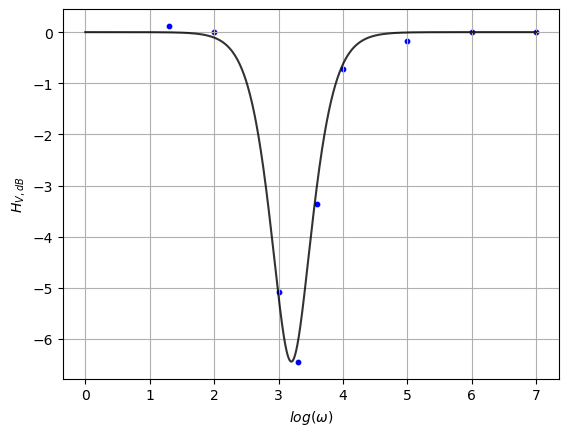

In [145]:
f = np.linspace(1, 1E7, int(1E6))
Omega = f*2*np.pi
Z = R1*R2*Omega*C-1/(Omega*C)
H_V_dB = 20 * np.log10(np.sqrt((2*R2*(R1+2*R2)+Z**2)**2+(Z**2)*(R1**2)) / ((R1+2*R2)**2 + Z**2)) #band-reject filter
log_omega = np.log10(f)

fig, ax = plt.subplots()
ax.plot(log_omega, H_V_dB, color="k", alpha=0.8)
ax.scatter(np.log10(df["f_in[Hz]"]), 20 * np.log10(df_Hv), s = 10, marker="o", color="b")

ax.set(xlabel="$log(\omega)$", ylabel="$H_{V,dB}$")

plt.grid()
plt.show()